In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
import os
os.listdir('Downloads/archive (4)/')

['Amazon-Product-Reviews - Amazon Product Review (1).csv']

In [5]:
df = pd.read_csv('Downloads/archive (4)/Amazon-Product-Reviews - Amazon Product Review (1).csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (30846, 16)


In [6]:
df.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,sentiment
0,US,11555559,R1QXC7AHHJBQ3O,B00IKPX4GY,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,Great love it,2015-08-31,1
1,US,31469372,R175VSRV6ZETOP,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,3,0,0,N,N,Lots of ads Slow processing speed Occasionally...,Lots of ads<br />Slow processing speed<br />Oc...,2015-08-31,0
2,US,26843895,R2HRFF78MWGY19,B00IKPW0UA,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Well thought out device,Excellent unit. The versatility of this table...,2015-08-31,1
3,US,19844868,R8Q39WPKYVSTX,B00LCHSHMS,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,4,0,0,N,N,Not all apps/games we were looking forward to ...,I bought this on Amazon Prime so I ended up bu...,2015-08-31,1
4,US,1189852,R3RL4C8YP2ZCJL,B00IKPZ5V6,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,All Amazon products continue to meet my expect...,2015-08-31,1


In [7]:
# Create sentiment based on star rating
def get_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['star_rating'].apply(get_sentiment)
print(df['sentiment'].value_counts())

sentiment
Positive    25767
Negative     2863
Neutral      2216
Name: count, dtype: int64


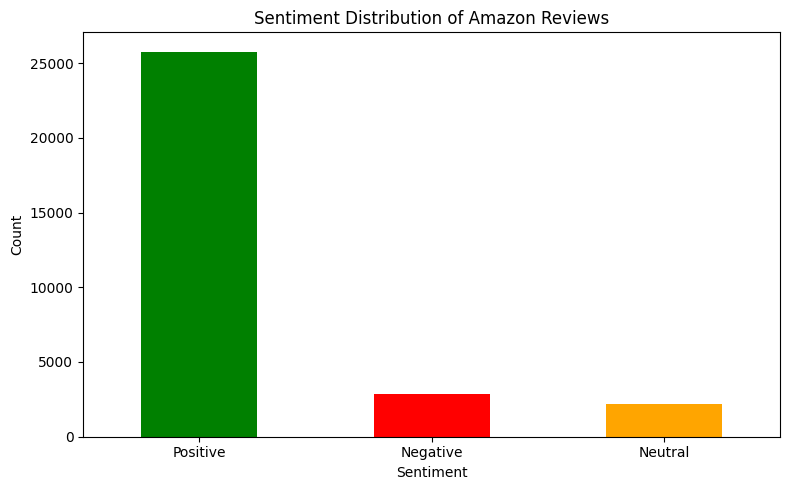

In [8]:
# Chart 1: Sentiment Distribution
plt.figure(figsize=(8,5))
colors = ['green', 'red', 'orange']
df['sentiment'].value_counts().plot(kind='bar', color=colors)
plt.title('Sentiment Distribution of Amazon Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\ramya.u\AppData\Local\Temp\ipykernel_8808\4022154084.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='star_rating', data=df, palette='RdYlGn')


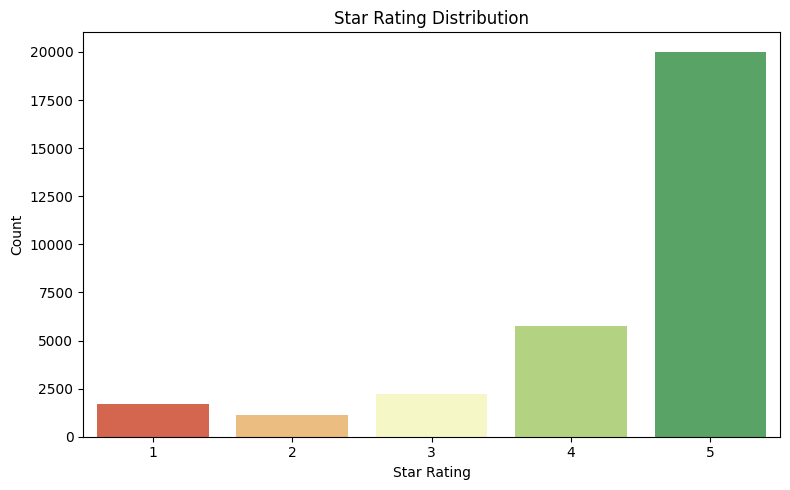

In [9]:
# Chart 2: Star Rating Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='star_rating', data=df, palette='RdYlGn')
plt.title('Star Rating Distribution')
plt.xlabel('Star Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

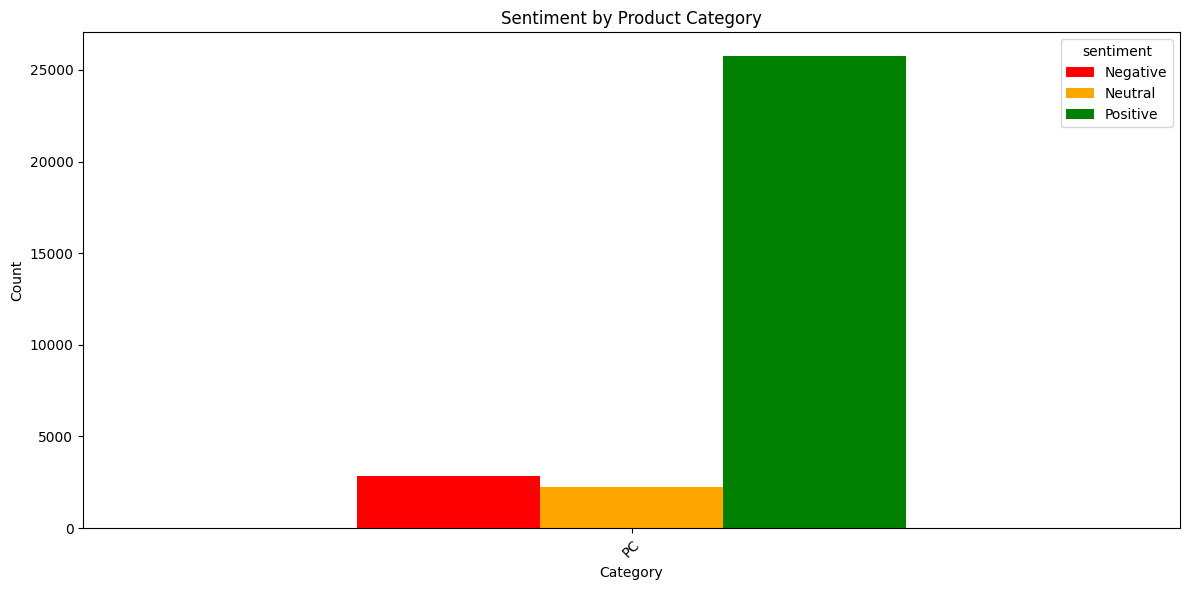

In [10]:
# Chart 3: Sentiment by Product Category
plt.figure(figsize=(12,6))
category_sentiment = df.groupby(['product_category', 'sentiment']).size().unstack()
category_sentiment.plot(kind='bar', figsize=(12,6), color=['red', 'orange', 'green'])
plt.title('Sentiment by Product Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

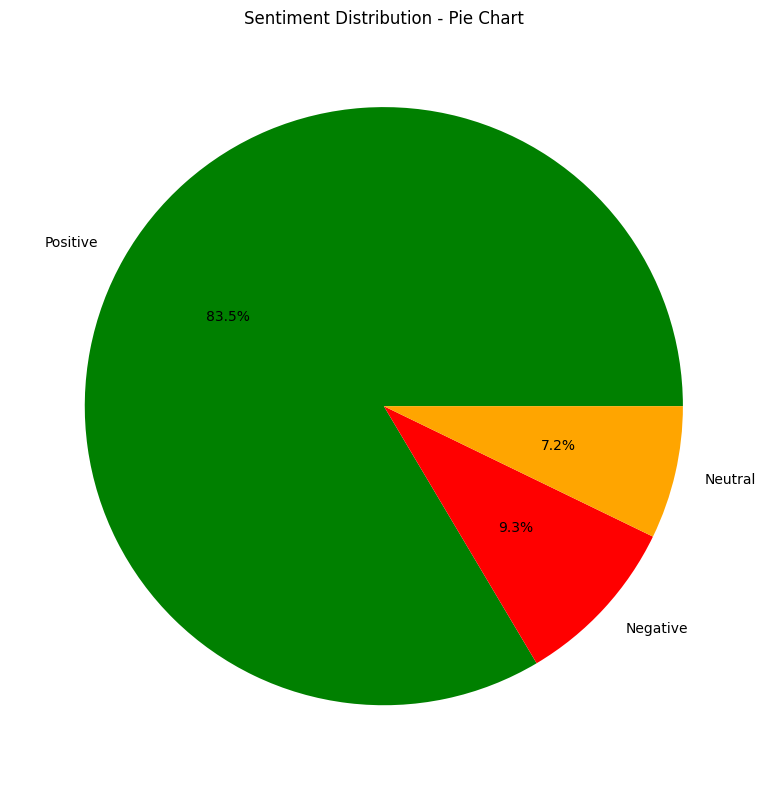

In [11]:
# Chart 4: Pie chart of sentiment
plt.figure(figsize=(8,8))
df['sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['green', 'red', 'orange'])
plt.title('Sentiment Distribution - Pie Chart')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [12]:
print("=" * 50)
print("SENTIMENT ANALYSIS SUMMARY")
print("=" * 50)
print(f"Total Reviews: {df.shape[0]}")
print(f"Positive Reviews: {df[df['sentiment']=='Positive'].shape[0]}")
print(f"Negative Reviews: {df[df['sentiment']=='Negative'].shape[0]}")
print(f"Neutral Reviews: {df[df['sentiment']=='Neutral'].shape[0]}")
print(f"Most Common Rating: {df['star_rating'].mode()[0]} stars")
print("=" * 50)
print("Sentiment Analysis Completed Successfully!")

SENTIMENT ANALYSIS SUMMARY
Total Reviews: 30846
Positive Reviews: 25767
Negative Reviews: 2863
Neutral Reviews: 2216
Most Common Rating: 5 stars
Sentiment Analysis Completed Successfully!
